# Compare Diffusion Transformer Inference With PRISM Observations

This notebook compares daily diffusion-transformer refined inference with PRISM over the configured spatial subdomain.

By default, climatology is skipped and the notebook creates a Maximum temperature (`tmax`) GIF over LA County showing Diffusion Transformer, PRISM, and their difference.

In [1]:
from pathlib import Path
import hashlib
import json
import re
import sys

import numpy as np
import pandas as pd
import xarray as xr
import yaml

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from dask.distributed import Client, LocalCluster

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY_AVAILABLE = True
except ImportError:
    ccrs = None
    cfeature = None
    CARTOPY_AVAILABLE = False

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "granitewxc").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "examples" / "NARR_PRISM"))
    sys.path.insert(0, str(REPO_ROOT))

from narr_prism_utils import case_output_dir, get_case_name, resolve_path
from granitewxc.utils.prism_evaluation import exact_axis_slice, validate_evaluation_coordinates
from granitewxc.utils.prism_grid import load_canonical_grid

print(f"Repository root: {REPO_ROOT}")
print(f"Cartopy available: {CARTOPY_AVAILABLE}")

Repository root: /data/granite-wxc
Cartopy available: True


## User Parameters

In [ ]:
# ===================== USER PARAMETERS (EDIT ME) =====================
CONFIG_PATH = REPO_ROOT / "examples" / "NARR_PRISM" / "NARR_PRISM_diffusion_unet.yaml"

# Leave as None to use data.target_dir and inference.output_dir from the YAML.
PRISM_ROOT = None
INFERENCE_OUTPUT_ROOT = None

# Climatology period. None means use the YAML inference period, clipped to files found.
MAKE_CLIMATOLOGY = True  # Skip all climatology work when regenerating only the GIF.
# For faster first runs, set a smaller range such as "2016-01-01" to "2016-12-31".
CLIMO_START = None
CLIMO_END = None
CLIMO_DATE_STEP = 1  # Exact daily climatology. Use 7 or 30 for a faster sampled preview.
USE_DASK_CLIMATOLOGY = True
CLIMO_DASK_WORKERS = 4  # Separate processes avoid NetCDF/HDF5 thread-lock contention.
CLIMO_DASK_BATCH_DAYS = 8  # Bounds memory while workers read days concurrently.
FORCE_RECOMPUTE_CLIMO = False  # Reuse the saved NetCDF climatology when available.
USE_PREPROCESSED_PRISM = False  # Optional canonical-target source; raw PRISM is faster on this filesystem.

# GIF period should stay modest because every frame reads PRISM + inference data.
GIF_START = "2016-08-01"
GIF_END = "2016-08-31"
GIF_FPS = 2
GIF_VARIABLE = "tmax"
MAKE_LA_COUNTY_GIF = True
# Bounding box that contains LA County.
LA_COUNTY_BOUNDS = {"lon_min": -118.95, "lon_max": -117.64, "lat_min": 33.70, "lat_max": 34.82}

# A tighter City of Los Angeles view, including downtown and the harbor.
MAKE_LA_CITY_GIF = True
LA_CITY_GIF_START = "2025-07-01"
LA_CITY_GIF_END = "2025-07-31"
LA_CITY_BOUNDS = {"lon_min": -118.67, "lon_max": -118.15, "lat_min": 33.70, "lat_max": 34.34}

OUTPUT_DIR = REPO_ROOT / "examples" / "NARR_PRISM" / "experiments" / "comparison_plots" / "diffusion_transformer"
MAKE_GIFS = True

# Map backgrounds use Cartopy PlateCarree when available.
USE_CARTOPY = True
SHOW_COUNTIES = False  # County boundaries can trigger a Natural Earth download.
MAP_FEATURE_SCALE = "10m"  # "10m", "50m", or "110m"
COUNTY_FEATURE_SCALE = "10m"
ANIMATION_FEATURE_SCALE = "10m"  # Highest-resolution Natural Earth coastline.
ANIMATION_SHOW_COUNTIES = True
ANIMATION_COASTLINE_LINEWIDTH = 1.0
ANIMATION_COUNTY_LINEWIDTH = 0.45
# ====================================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Comparison artifacts will be written to: {OUTPUT_DIR}")

Comparison artifacts will be written to: /data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_transformer


## Load Configuration

In [3]:
with open(CONFIG_PATH, "r", encoding="utf-8") as fh:
    cfg = yaml.safe_load(fh)

data_cfg = cfg["data"]
case_name = get_case_name(cfg)
target_variables = list(data_cfg.get("target_variables", ["ppt", "tmax", "tmin"]))
spatial_subset = data_cfg.get("spatial_subset", {}) or {}

prism_root = Path(PRISM_ROOT) if PRISM_ROOT is not None else Path(data_cfg["target_dir"])
refinement_cfg = cfg.get("model", {}).get("refinement", {}) or {}
refinement_type = str(refinement_cfg.get("type", ""))
if not refinement_cfg.get("enabled", False) or refinement_type != "diffusion_transformer":
    raise ValueError(
        f"{CONFIG_PATH} must enable model.refinement.type=diffusion_transformer"
    )

if INFERENCE_OUTPUT_ROOT is not None:
    inference_root = Path(INFERENCE_OUTPUT_ROOT)
else:
    base_inference_root = resolve_path(
        cfg.get("inference", {}).get(
            "refinement_output_dir",
            cfg.get("inference", {}).get(
                "output_dir",
                "./examples/NARR_PRISM/experiments/inference_output",
            ),
        )
    )
    inference_root = base_inference_root / f"refinement_{refinement_type}"
inference_dir = case_output_dir(inference_root, case_name)
preprocessed_case_dir = case_output_dir(resolve_path(data_cfg["preprocessed_dir"]), case_name)
canonical_grid = load_canonical_grid(preprocessed_case_dir)

yaml_start = pd.Timestamp(cfg["dates"]["inference"]["start"])
yaml_end = pd.Timestamp(cfg["dates"]["inference"]["end"])

print(f"Config: {CONFIG_PATH}")
print(f"Case name: {case_name}")
print(f"Variables: {target_variables}")
print(f"PRISM root: {prism_root}")
print(f"Refinement type: {refinement_type}")
print(f"Inference dir: {inference_dir}")
print(f"Canonical PRISM grid: {canonical_grid.shape} ({canonical_grid.fingerprint[:12]})")
print(f"PRISM comparison source: {'canonical preprocessed targets' if USE_PREPROCESSED_PRISM else 'raw daily files'}")
print(f"YAML inference period: {yaml_start.date()} to {yaml_end.date()}")
print(f"Spatial subset: {spatial_subset}")

Config: /data/granite-wxc/examples/NARR_PRISM/NARR_PRISM_diffusion_transformer.yaml
Case name: narr_prism_California
Variables: ['ppt', 'tmax', 'tmin']
PRISM root: /data/PRISM/prism_daily_800m_an
Refinement type: diffusion_transformer
Inference dir: /data2/granite-wxc-artifacts/NARR_PRISM/experiments/inference_output/refinement_diffusion_transformer/narr_prism_California
Canonical PRISM grid: (1024, 1024) (f062e76bd115)
PRISM comparison source: raw daily files
YAML inference period: 2016-01-01 to 2025-12-31
Spatial subset: {'enabled': True, 'lat_min': 32.55, 'lat_max': 41.075, 'lon_min': -124.45, 'lon_max': -115.925}


## Helper Functions

In [4]:
DATE_RE = re.compile(r"_(\d{8})\.nc$")

VAR_LABELS = {
    "ppt": "Precipitation",
    "tmax": "Maximum temperature",
    "tmin": "Minimum temperature",
}
VAR_UNITS = {"ppt": "mm/day", "tmax": "deg C", "tmin": "deg C"}
VAR_CMAPS = {"ppt": "viridis", "tmax": "magma", "tmin": "plasma"}


def inference_file(date):
    token = pd.Timestamp(date).strftime("%Y%m%d")
    return inference_dir / f"{case_name}_{refinement_type}_refined_{token}.nc"


def prism_file(var, date):
    stamp = pd.Timestamp(date)
    token = stamp.strftime("%Y%m%d")
    return prism_root / var / str(stamp.year) / f"prism_{var}_us_30s_{token}.nc"


def preprocessed_prism_file(date):
    token = pd.Timestamp(date).strftime("%Y%m%d")
    return preprocessed_case_dir / "inference" / f"narr_prism_{token}.nc"


def dates_from_inference_files():
    dates = []
    for path in sorted(inference_dir.glob(f"{case_name}_{refinement_type}_refined_*.nc")):
        match = DATE_RE.search(path.name)
        if match:
            dates.append(pd.Timestamp(match.group(1)))
    return pd.DatetimeIndex(dates)


def open_prism_day(var, date, target_lat=None, target_lon=None):
    if USE_PREPROCESSED_PRISM:
        targets = open_prism_targets_day(date, target_lat=target_lat, target_lon=target_lon, variables=[var])
        try:
            return targets[var].load()
        finally:
            targets.close()

    path = prism_file(var, date)
    if not path.exists():
        raise FileNotFoundError(path)
    with xr.open_dataset(path) as ds:
        name = var if var in ds.data_vars else "Band1"
        lat_slice = exact_axis_slice(ds.lat.values, canonical_grid.lat, name="latitude", context=str(path))
        lon_slice = exact_axis_slice(ds.lon.values, canonical_grid.lon, name="longitude", context=str(path))
        da = ds[name].isel(lat=lat_slice, lon=lon_slice).astype("float32")
        if target_lat is not None and target_lon is not None:
            validate_evaluation_coordinates(canonical_grid.lat, target_lat.values, name="latitude", context=str(path))
            validate_evaluation_coordinates(canonical_grid.lon, target_lon.values, name="longitude", context=str(path))
        return da.load()


def open_prism_targets_day(date, target_lat=None, target_lon=None, variables=None):
    variables = target_variables if variables is None else list(variables)
    if not USE_PREPROCESSED_PRISM:
        return xr.Dataset({
            var: open_prism_day(var, date, target_lat=target_lat, target_lon=target_lon)
            for var in variables
        })

    path = preprocessed_prism_file(date)
    if not path.exists():
        raise FileNotFoundError(path)
    ds = xr.open_dataset(path)
    try:
        if ds.attrs.get("prism_grid_fingerprint") != canonical_grid.fingerprint:
            raise ValueError(f"{path}: preprocessed PRISM grid fingerprint does not match the canonical grid")
        validate_evaluation_coordinates(canonical_grid.lat, ds.lat.values, name="latitude", context=str(path))
        validate_evaluation_coordinates(canonical_grid.lon, ds.lon.values, name="longitude", context=str(path))
        if target_lat is not None and target_lon is not None:
            validate_evaluation_coordinates(canonical_grid.lat, target_lat.values, name="latitude", context=str(path))
            validate_evaluation_coordinates(canonical_grid.lon, target_lon.values, name="longitude", context=str(path))
        names = {f"target_{var}": var for var in variables}
        missing = [name for name in names if name not in ds.data_vars]
        if missing:
            raise KeyError(f"{path}: missing preprocessed target variables {missing}")
        return ds[list(names)].rename(names).load()
    except Exception:
        ds.close()
        raise


def open_inference_day(date, variables=None):
    path = inference_file(date)
    if not path.exists():
        raise FileNotFoundError(path)
    ds = xr.open_dataset(path)
    try:
        validate_evaluation_coordinates(canonical_grid.lat, ds.lat.values, name="latitude", context=str(path))
        validate_evaluation_coordinates(canonical_grid.lon, ds.lon.values, name="longitude", context=str(path))
        selected = ds if variables is None else ds[list(variables)]
        return selected.load()
    except Exception:
        ds.close()
        raise


def date_range(start, end):
    return pd.date_range(pd.Timestamp(start), pd.Timestamp(end), freq="D")


def existing_common_dates(start, end, variables=None):
    variables = target_variables if variables is None else list(variables)
    dates = []
    for date in date_range(start, end):
        if not inference_file(date).exists():
            continue
        truth_exists = (
            preprocessed_prism_file(date).exists()
            if USE_PREPROCESSED_PRISM
            else all(prism_file(var, date).exists() for var in variables)
        )
        if truth_exists:
            dates.append(date)
    return pd.DatetimeIndex(dates)


def symmetric_limits(da, q=0.98):
    vals = np.asarray(da.values).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return -1.0, 1.0
    lim = float(np.nanquantile(np.abs(vals), q))
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0
    return -lim, lim


def field_limits(*arrays, q=0.02):
    vals = np.concatenate([np.asarray(a.values).ravel() for a in arrays])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 0.0, 1.0
    lo = float(np.nanquantile(vals, q))
    hi = float(np.nanquantile(vals, 1 - q))
    if lo == hi:
        hi = lo + 1.0
    return lo, hi


def cartopy_enabled():
    return bool(USE_CARTOPY and CARTOPY_AVAILABLE)


def map_subplot_kw():
    return {"projection": ccrs.PlateCarree()} if cartopy_enabled() else {}


def map_plot_kwargs():
    return {"transform": ccrs.PlateCarree()} if cartopy_enabled() else {}


def map_extent(da, pad_fraction=0.02):
    lon0 = float(da.lon.min())
    lon1 = float(da.lon.max())
    lat0 = float(da.lat.min())
    lat1 = float(da.lat.max())
    lon_pad = max((lon1 - lon0) * pad_fraction, 0.01)
    lat_pad = max((lat1 - lat0) * pad_fraction, 0.01)
    return [lon0 - lon_pad, lon1 + lon_pad, lat0 - lat_pad, lat1 + lat_pad]


def add_map_background(
    ax,
    da,
    *,
    show_counties=None,
    feature_scale=None,
    coastline_linewidth=0.7,
    county_linewidth=0.25,
):
    if not cartopy_enabled():
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        return

    show_counties = SHOW_COUNTIES if show_counties is None else show_counties
    feature_scale = MAP_FEATURE_SCALE if feature_scale is None else feature_scale
    data_crs = ccrs.PlateCarree()
    ax.set_extent(map_extent(da), crs=data_crs)
    ax.coastlines(resolution=feature_scale, linewidth=coastline_linewidth, color="0.08", zorder=5)
    ax.add_feature(cfeature.BORDERS.with_scale(feature_scale), linewidth=0.5, edgecolor="0.25", zorder=5)
    ax.add_feature(cfeature.STATES.with_scale(feature_scale), linewidth=0.65, edgecolor="0.15", zorder=5)
    if show_counties:
        counties = cfeature.NaturalEarthFeature(
            "cultural",
            "admin_2_counties",
            COUNTY_FEATURE_SCALE,
            facecolor="none",
        )
        ax.add_feature(counties, linewidth=county_linewidth, edgecolor="0.25", zorder=6)
    gl = ax.gridlines(draw_labels=True, linewidth=0.25, color="0.45", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

## Discover Available Dates

In [5]:
inference_dates = dates_from_inference_files()
if len(inference_dates) == 0:
    raise FileNotFoundError(f"No inference files found in {inference_dir}")

print(f"Inference files: {len(inference_dates)} ({inference_dates.min().date()} to {inference_dates.max().date()})")

if MAKE_CLIMATOLOGY:
    climo_start = pd.Timestamp(CLIMO_START) if CLIMO_START else max(yaml_start, inference_dates.min())
    climo_end = pd.Timestamp(CLIMO_END) if CLIMO_END else min(yaml_end, inference_dates.max())
    if not isinstance(CLIMO_DATE_STEP, int) or CLIMO_DATE_STEP < 1:
        raise ValueError("CLIMO_DATE_STEP must be a positive integer")
    common_dates = existing_common_dates(climo_start, climo_end)[::CLIMO_DATE_STEP]

    if len(common_dates) == 0:
        raise FileNotFoundError(f"No common inference/PRISM dates found between {climo_start.date()} and {climo_end.date()}")

    common_dates_hash = hashlib.sha256(common_dates.asi8.tobytes()).hexdigest()
    inference_source_digest = hashlib.sha256()
    for source_path in (inference_file(date) for date in common_dates):
        stat = source_path.stat()
        inference_source_digest.update(str(source_path.resolve()).encode())
        inference_source_digest.update(f"{stat.st_size}:{stat.st_mtime_ns}".encode())
    with xr.open_dataset(inference_file(common_dates[0])) as identity_ds:
        inference_model_identity = {
            key: str(identity_ds.attrs.get(key, ""))
            for key in ("checkpoint", "phase1_checkpoint", "phase2_checkpoint",
                        "phase1_fingerprint", "phase2_fingerprint",
                        "refinement_type", "config_fingerprint")
        }
    inference_source_digest.update(json.dumps(inference_model_identity, sort_keys=True).encode())
    inference_source_hash = inference_source_digest.hexdigest()
    climo_path = OUTPUT_DIR / (
        f"{case_name}_climatology_{common_dates.min():%Y%m%d}_{common_dates.max():%Y%m%d}_"
        f"{inference_source_hash[:12]}.nc"
    )

    print(f"Climatology dates: {len(common_dates)} ({common_dates.min().date()} to {common_dates.max().date()}, step={CLIMO_DATE_STEP})")
    print(f"Climatology NetCDF: {climo_path}")
    sample = open_inference_day(common_dates[0])
    print(sample)
    sample.close()
else:
    common_dates = pd.DatetimeIndex([])
    climo_path = None
    print("Skipped climatology discovery (MAKE_CLIMATOLOGY=False).")

Inference files: 3653 (2016-01-01 to 2025-12-31)
Climatology dates: 3653 (2016-01-01 to 2025-12-31, step=1)
Climatology NetCDF: /data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_transformer/narr_prism_California_climatology_20160101_20251231_9a0b8229fc2e.nc
<xarray.Dataset> Size: 165MB
Dimensions:               (lat: 1024, lon: 1024, time: 1)
Coordinates:
  * lat                   (lat) float64 8kB 32.55 32.56 32.57 ... 41.07 41.08
  * lon                   (lon) float64 8kB -124.5 -124.4 ... -115.9 -115.9
  * time                  (time) datetime64[ns] 8B 2016-01-01
Data variables: (12/40)
    prism_valid_mask      (lat, lon) uint8 1MB 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1
    ppt                   (time, lat, lon) float32 4MB nan nan ... 0.3017 0.303
    ppt_phase1            (time, lat, lon) float32 4MB nan nan nan ... 0.0 0.0
    ppt_member_000        (time, lat, lon) float32 4MB nan nan nan ... 0.0 0.0
    ppt_member_001        (time, lat, lon) float32 4MB n

## Compute Climatology Maps

The default path uses Dask worker processes to read a small batch of independent days concurrently. Each task opens one inference file and the matching PRISM files, loads only the required values, and closes every file before returning. The main process adds those values to float64 running sums and per-pixel valid-day counts, then divides once at the end. This keeps memory and open-file usage bounded while producing the same result as the sequential streaming calculation.

Set `USE_DASK_CLIMATOLOGY = False` for the single-process fallback. Completed climatologies are cached as validated NetCDF files; set `FORCE_RECOMPUTE_CLIMO = True` only when source data changed.

In [6]:
CLIMO_FIELD_NAMES = ("inference", "prism", "bias", "rmse", "count")


def climo_var_name(var, field):
    return f"{var}_{field}"


def climo_from_dataset(ds):
    return {
        var: {field: ds[climo_var_name(var, field)] for field in CLIMO_FIELD_NAMES}
        for var in target_variables
    }


def climo_cache_matches(path):
    if not path.exists():
        return False
    required = {
        climo_var_name(var, field)
        for var in target_variables
        for field in CLIMO_FIELD_NAMES
    }
    try:
        with xr.open_dataset(path) as cached:
            return (
                required.issubset(cached.data_vars)
                and cached.attrs.get("case_name") == case_name
                and cached.attrs.get("prism_source") == ("preprocessed" if USE_PREPROCESSED_PRISM else "raw")
                and cached.attrs.get("grid_fingerprint") == canonical_grid.fingerprint
                and cached.attrs.get("start_date") == common_dates.min().strftime("%Y-%m-%d")
                and cached.attrs.get("end_date") == common_dates.max().strftime("%Y-%m-%d")
                and int(cached.attrs.get("date_count", -1)) == len(common_dates)
                and cached.attrs.get("dates_hash") == common_dates_hash
                and cached.attrs.get("inference_source_hash") == inference_source_hash
                and cached.attrs.get("inference_model_identity") == json.dumps(inference_model_identity, sort_keys=True)
                and np.array_equal(cached.lat.values, canonical_grid.lat)
                and np.array_equal(cached.lon.values, canonical_grid.lon)
            )
    except (OSError, ValueError, KeyError):
        return False


def finalize_mean(total, count):
    result = np.full(total.shape, np.nan, dtype=np.float64)
    np.divide(total, count, out=result, where=count > 0)
    return result.astype("float32")


def load_climatology_day(date):
    """Load one day in a worker process and close every source before returning."""
    inf_ds = open_inference_day(date, variables=target_variables)
    obs_ds = None
    try:
        obs_ds = open_prism_targets_day(date, target_lat=inf_ds.lat, target_lon=inf_ds.lon)
        return {
            var: (
                np.asarray(inf_ds[var].isel(time=0).values, dtype="float32"),
                np.asarray(obs_ds[var].values, dtype="float32"),
            )
            for var in target_variables
        }
    finally:
        if obs_ds is not None:
            obs_ds.close()
        inf_ds.close()


def accumulate_climatology_day(accumulators, fields, difference):
    for var, (inf, obs) in fields.items():
        valid = np.isfinite(inf)
        np.logical_and(valid, np.isfinite(obs), out=valid)
        acc = accumulators[var]

        # Sum first and divide once at the end. Per-pixel counts preserve the
        # correct mean where either product contains missing values.
        np.add(acc["inference"], inf, out=acc["inference"], where=valid)
        np.add(acc["prism"], obs, out=acc["prism"], where=valid)
        np.subtract(inf, obs, out=difference)
        np.add(acc["bias"], difference, out=acc["bias"], where=valid)
        np.square(difference, out=difference)
        np.add(acc["sumsq"], difference, out=acc["sumsq"], where=valid)
        np.add(acc["count"], valid, out=acc["count"])


def stream_climatology_days(accumulators, dates, difference):
    for i, date in enumerate(dates, start=1):
        if i == 1 or i % 100 == 0 or i == len(dates):
            print(f"[{i:>5}/{len(dates)}] {date.date()}")
        accumulate_climatology_day(accumulators, load_climatology_day(date), difference)


def dask_climatology_days(accumulators, dates, difference):
    if not isinstance(CLIMO_DASK_WORKERS, int) or CLIMO_DASK_WORKERS < 1:
        raise ValueError("CLIMO_DASK_WORKERS must be a positive integer")
    if not isinstance(CLIMO_DASK_BATCH_DAYS, int) or CLIMO_DASK_BATCH_DAYS < 1:
        raise ValueError("CLIMO_DASK_BATCH_DAYS must be a positive integer")

    worker_count = min(CLIMO_DASK_WORKERS, len(dates))
    print(f"Dask climatology: {worker_count} processes, batches of {CLIMO_DASK_BATCH_DAYS} days")
    cluster = LocalCluster(
        n_workers=worker_count,
        threads_per_worker=1,
        processes=True,
        dashboard_address=None,
    )
    try:
        with Client(cluster) as client:
            for start in range(0, len(dates), CLIMO_DASK_BATCH_DAYS):
                batch = list(dates[start:start + CLIMO_DASK_BATCH_DAYS])
                futures = client.map(load_climatology_day, batch, pure=False)
                daily_fields = client.gather(futures)
                for fields in daily_fields:
                    accumulate_climatology_day(accumulators, fields, difference)
                completed = start + len(batch)
                print(f"[{completed:>5}/{len(dates)}] {batch[-1].date()}")
    finally:
        cluster.close()


if not MAKE_CLIMATOLOGY:
    climo_ds = None
    climo = None
    print("Skipped climatology calculation (MAKE_CLIMATOLOGY=False).")
elif not FORCE_RECOMPUTE_CLIMO and climo_cache_matches(climo_path):
    climo_ds = xr.load_dataset(climo_path)
    climo = climo_from_dataset(climo_ds)
    print(f"Loaded cached climatology: {climo_path}")
else:
    # NumPy ufuncs update these arrays in place. This avoids the repeated
    # xarray alignment and full-grid temporary allocations in the old loop.
    shape = canonical_grid.shape
    accumulators = {
        var: {
            "inference": np.zeros(shape, dtype="float64"),
            "prism": np.zeros(shape, dtype="float64"),
            "bias": np.zeros(shape, dtype="float64"),
            "sumsq": np.zeros(shape, dtype="float64"),
            "count": np.zeros(shape, dtype="int32"),
        }
        for var in target_variables
    }
    difference = np.empty(shape, dtype="float32")

    if USE_DASK_CLIMATOLOGY and len(common_dates) > 1:
        dask_climatology_days(accumulators, common_dates, difference)
    else:
        stream_climatology_days(accumulators, common_dates, difference)

    data_vars = {}
    for var, acc in accumulators.items():
        data_vars[climo_var_name(var, "inference")] = (("lat", "lon"), finalize_mean(acc["inference"], acc["count"]))
        data_vars[climo_var_name(var, "prism")] = (("lat", "lon"), finalize_mean(acc["prism"], acc["count"]))
        data_vars[climo_var_name(var, "bias")] = (("lat", "lon"), finalize_mean(acc["bias"], acc["count"]))
        rmse = finalize_mean(acc["sumsq"], acc["count"])
        np.sqrt(rmse, out=rmse)
        data_vars[climo_var_name(var, "rmse")] = (("lat", "lon"), rmse)
        data_vars[climo_var_name(var, "count")] = (("lat", "lon"), acc["count"])

    climo_ds = xr.Dataset(
        data_vars=data_vars,
        coords={"lat": canonical_grid.lat, "lon": canonical_grid.lon},
        attrs={
            "description": "NARR-to-PRISM inference climatology and error statistics",
            "case_name": case_name,
            "prism_source": "preprocessed" if USE_PREPROCESSED_PRISM else "raw",
            "grid_fingerprint": canonical_grid.fingerprint,
            "start_date": common_dates.min().strftime("%Y-%m-%d"),
            "end_date": common_dates.max().strftime("%Y-%m-%d"),
            "date_count": len(common_dates),
            "dates_hash": common_dates_hash,
            "inference_source_hash": inference_source_hash,
            "inference_model_identity": json.dumps(inference_model_identity, sort_keys=True),
            "calculation_engine": "dask-processes" if USE_DASK_CLIMATOLOGY else "streaming",
        },
    )
    for var in target_variables:
        for field in ("inference", "prism", "bias", "rmse"):
            climo_ds[climo_var_name(var, field)].attrs.update(
                long_name=f"{VAR_LABELS.get(var, var)} {field}",
                units=VAR_UNITS.get(var, ""),
            )
        climo_ds[climo_var_name(var, "count")].attrs.update(
            long_name=f"{VAR_LABELS.get(var, var)} valid-pair count",
            units="days",
        )
    temporary_path = climo_path.with_suffix(".tmp.nc")
    climo_ds.to_netcdf(temporary_path)
    temporary_path.replace(climo_path)
    climo = climo_from_dataset(climo_ds)
    print(f"Saved climatology: {climo_path}")

if MAKE_CLIMATOLOGY:
    print("Climatology ready.")

Dask climatology: 4 processes, batches of 8 days
[    8/3653] 2016-01-08
[   16/3653] 2016-01-16
[   24/3653] 2016-01-24
[   32/3653] 2016-02-01
[   40/3653] 2016-02-09
[   48/3653] 2016-02-17
[   56/3653] 2016-02-25
[   64/3653] 2016-03-04
[   72/3653] 2016-03-12
[   80/3653] 2016-03-20
[   88/3653] 2016-03-28
[   96/3653] 2016-04-05
[  104/3653] 2016-04-13
[  112/3653] 2016-04-21
[  120/3653] 2016-04-29
[  128/3653] 2016-05-07
[  136/3653] 2016-05-15
[  144/3653] 2016-05-23
[  152/3653] 2016-05-31
[  160/3653] 2016-06-08
[  168/3653] 2016-06-16
[  176/3653] 2016-06-24
[  184/3653] 2016-07-02
[  192/3653] 2016-07-10
[  200/3653] 2016-07-18
[  208/3653] 2016-07-26
[  216/3653] 2016-08-03
[  224/3653] 2016-08-11
[  232/3653] 2016-08-19
[  240/3653] 2016-08-27
[  248/3653] 2016-09-04
[  256/3653] 2016-09-12
[  264/3653] 2016-09-20
[  272/3653] 2016-09-28
[  280/3653] 2016-10-06
[  288/3653] 2016-10-14
[  296/3653] 2016-10-22
[  304/3653] 2016-10-30
[  312/3653] 2016-11-07
[  320/3653] 20

## Plot Consolidated Climatology Map

The layout matches the requested comparison: Prithvi U-Net on the top row, PRISM on the bottom row, and one column per target variable. Each pair uses the same color limits.

/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_transformer/narr_prism_California_diffusion_transformer_prism_climatology_comparison.png


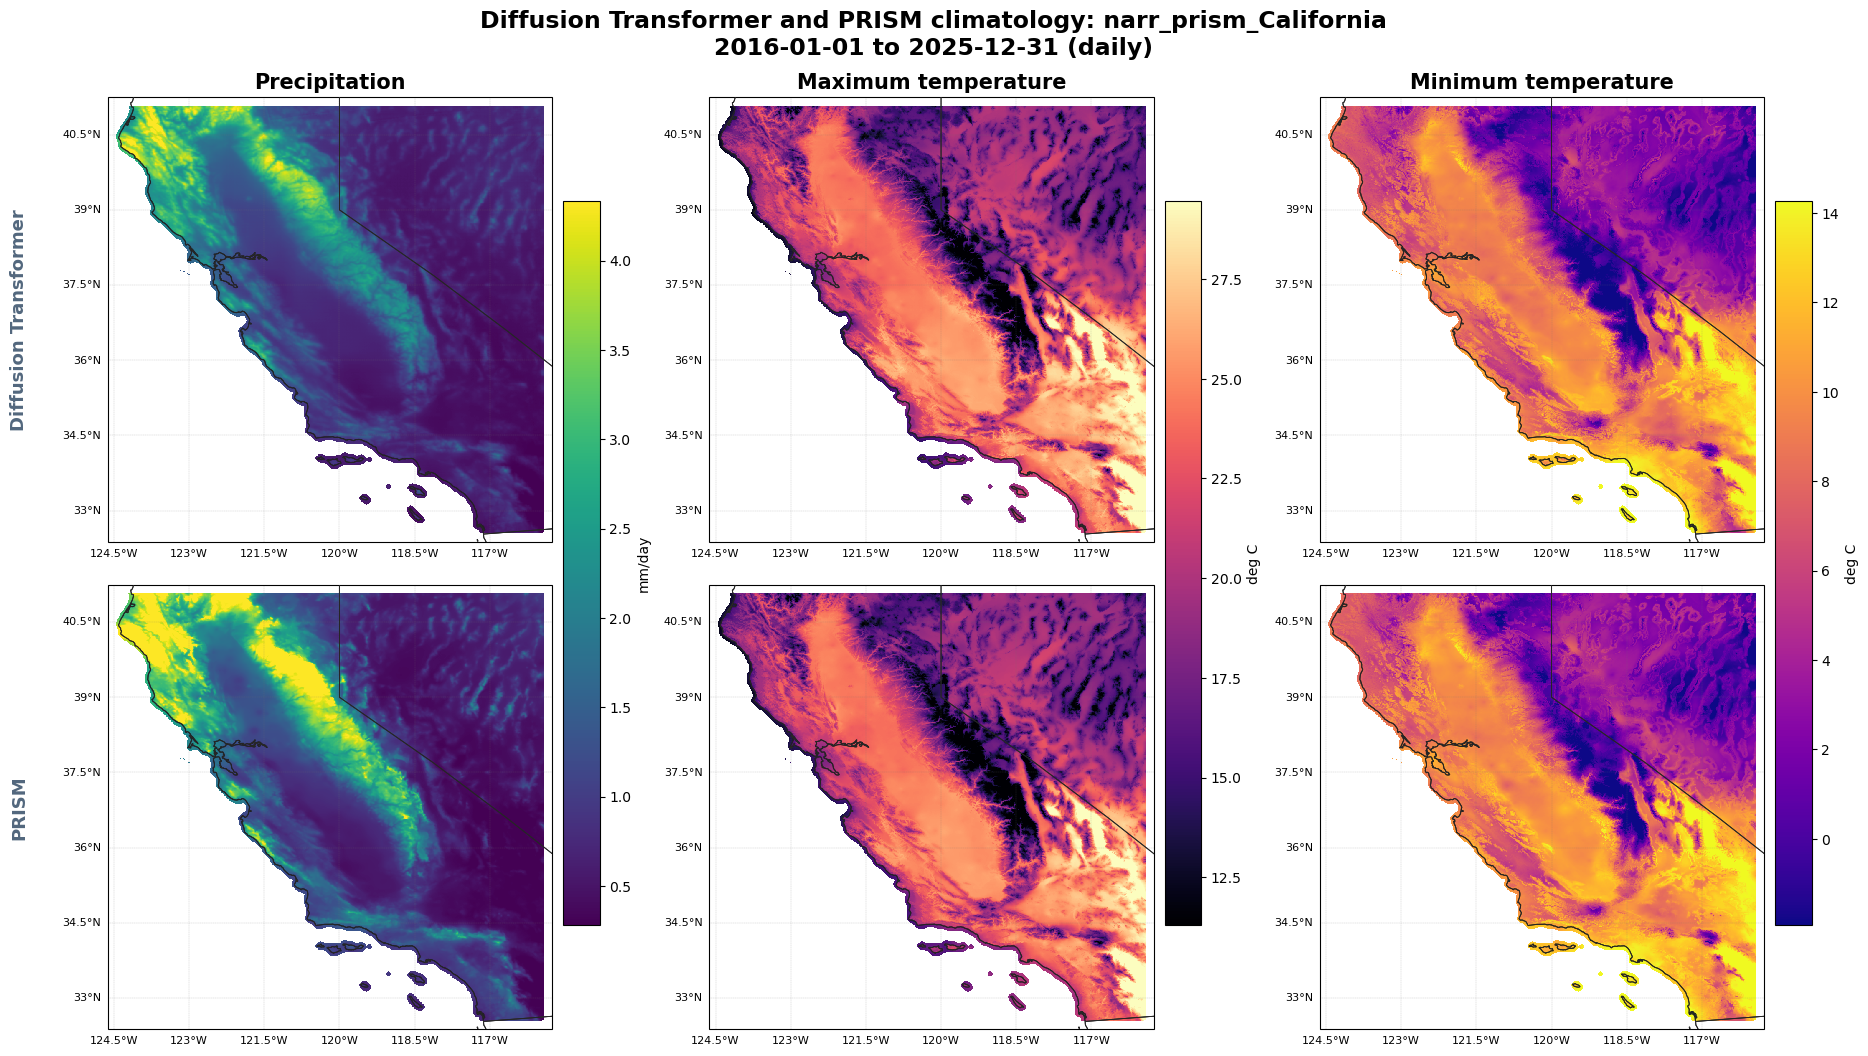

In [7]:
def plot_climatology_comparison():
    variables = [var for var in ("ppt", "tmax", "tmin") if var in target_variables]
    fig, axes = plt.subplots(
        2,
        len(variables),
        figsize=(6.2 * len(variables), 10.5),
        constrained_layout=True,
        subplot_kw=map_subplot_kw(),
        squeeze=False,
    )

    column_titles = {
        "ppt": "Precipitation",
        "tmax": "Maximum temperature",
        "tmin": "Minimum temperature",
    }
    row_fields = [("inference", "Diffusion Transformer"), ("prism", "PRISM")]

    for col, var in enumerate(variables):
        inf = climo[var]["inference"]
        obs = climo[var]["prism"]
        vmin, vmax = field_limits(inf, obs)
        column_images = []

        for row, (field, row_label) in enumerate(row_fields):
            ax = axes[row, col]
            da = climo[var][field]
            im = da.plot(
                ax=ax,
                x="lon",
                y="lat",
                cmap=VAR_CMAPS.get(var, "viridis"),
                vmin=vmin,
                vmax=vmax,
                add_colorbar=False,
                **map_plot_kwargs(),
            )
            add_map_background(ax, da)
            ax.set_title(column_titles[var] if row == 0 else "", fontsize=15, fontweight="bold")
            column_images.append(im)

            if col == 0:
                ax.text(
                    -0.20,
                    0.5,
                    row_label,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=13,
                    fontweight="bold",
                    color="#52677d",
                )

        cbar = fig.colorbar(column_images[0], ax=axes[:, col], shrink=0.76, pad=0.025)
        cbar.set_label(VAR_UNITS.get(var, ""))

    start = common_dates.min().strftime("%Y-%m-%d")
    end = common_dates.max().strftime("%Y-%m-%d")
    sampling = "daily" if CLIMO_DATE_STEP == 1 else f"every {CLIMO_DATE_STEP} days"
    fig.suptitle(
        f"Diffusion Transformer and PRISM climatology: {case_name}\n{start} to {end} ({sampling})",
        fontsize=17,
        fontweight="bold",
    )
    out = OUTPUT_DIR / f"{case_name}_diffusion_transformer_prism_climatology_comparison.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print(out)
    return fig


if MAKE_CLIMATOLOGY:
    climatology_figure = plot_climatology_comparison()
    plt.show()
else:
    climatology_figure = None
    print("Skipped climatology plot.")

## Summary Metrics

In [8]:
if MAKE_CLIMATOLOGY:
    rows = []
    for var in target_variables:
        rows.append({
            "variable": var,
            "mean_inference": float(climo[var]["inference"].mean(skipna=True)),
            "mean_prism": float(climo[var]["prism"].mean(skipna=True)),
            "mean_bias": float(climo[var]["bias"].mean(skipna=True)),
            "spatial_mean_rmse": float(climo[var]["rmse"].mean(skipna=True)),
            "valid_grid_cells": int((climo[var]["count"] > 0).sum()),
        })

    metrics = pd.DataFrame(rows)
    metrics_path = OUTPUT_DIR / f"{case_name}_climatology_metrics.csv"
    metrics.to_csv(metrics_path, index=False)
    print(metrics_path)
    metrics
else:
    metrics = pd.DataFrame()
    metrics_path = None
    print("Skipped climatology metrics.")

metrics

/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_transformer/narr_prism_California_climatology_metrics.csv


,variable,mean_inference,mean_prism,mean_bias,spatial_mean_rmse,valid_grid_cells
0,ppt,1.159532,1.379408,-0.219876,3.429570,714742
1,tmax,21.011919,20.506580,0.505339,2.326194,714742
2,tmin,6.289078,6.852247,-0.563170,2.272407,714742


## Maximum Temperature GIFs Over Los Angeles

Each frame shows Maximum temperature from the Diffusion Transformer, PRISM, and their difference. The notebook can create both an LA County view and a tighter City of Los Angeles view.

In [9]:
def subset_to_bounds(da, bounds):
    lat_slice = slice(bounds["lat_min"], bounds["lat_max"])
    lon_slice = slice(bounds["lon_min"], bounds["lon_max"])
    if da.lat.values[0] > da.lat.values[-1]:
        lat_slice = slice(bounds["lat_max"], bounds["lat_min"])
    if da.lon.values[0] > da.lon.values[-1]:
        lon_slice = slice(bounds["lon_max"], bounds["lon_min"])

    subset = da.sel(lat=lat_slice, lon=lon_slice)
    if subset.sizes.get("lat", 0) == 0 or subset.sizes.get("lon", 0) == 0:
        raise ValueError(f"Animation bounds {bounds} do not overlap the data grid")
    return subset


def load_animation_frames(var, dates, bounds):
    frames = []
    for i, date in enumerate(dates, start=1):
        print(f"{var}: frame {i}/{len(dates)} {date.date()}")
        inf_ds = open_inference_day(date, variables=[var])
        try:
            full_inf = inf_ds[var].isel(time=0).astype("float32")
            full_obs = open_prism_day(var, date, target_lat=inf_ds.lat, target_lon=inf_ds.lon)
            inf = subset_to_bounds(full_inf, bounds)
            obs = subset_to_bounds(full_obs, bounds)
            inf = inf.where(np.isfinite(obs))
            frames.append((date, inf, obs, inf - obs))
        finally:
            inf_ds.close()
    return frames


def make_comparison_gif(var, dates, bounds, region_label, region_slug):
    frames = load_animation_frames(var, dates, bounds)
    if not frames:
        print(f"No frames for {var}")
        return None

    vmin, vmax = field_limits(*[item for _, inf, obs, _ in frames for item in (inf, obs)])
    diffs = [diff for _, _, _, diff in frames]
    dmin, dmax = symmetric_limits(xr.concat(diffs, dim="frame"))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True, subplot_kw=map_subplot_kw())
    titles = ["Diffusion Transformer", "PRISM", "Diffusion Transformer - PRISM"]
    cmaps = [VAR_CMAPS.get(var, "viridis"), VAR_CMAPS.get(var, "viridis"), "RdBu_r"]
    limits = [(vmin, vmax), (vmin, vmax), (dmin, dmax)]

    images = []
    _, first_inf, first_obs, first_diff = frames[0]
    for ax, da, title, cmap, (lo, hi) in zip(axes, [first_inf, first_obs, first_diff], titles, cmaps, limits):
        im = da.plot(ax=ax, x="lon", y="lat", cmap=cmap, vmin=lo, vmax=hi, add_colorbar=False, **map_plot_kwargs())
        add_map_background(
            ax,
            da,
            show_counties=ANIMATION_SHOW_COUNTIES,
            feature_scale=ANIMATION_FEATURE_SCALE,
            coastline_linewidth=ANIMATION_COASTLINE_LINEWIDTH,
            county_linewidth=ANIMATION_COUNTY_LINEWIDTH,
        )
        ax.set_title(title)
        images.append(im)

    # Diffusion Transformer and PRISM use identical limits and one shared colorbar.
    temperature_cbar = fig.colorbar(images[0], ax=axes[:2], shrink=0.82, pad=0.025)
    temperature_cbar.set_label(VAR_UNITS.get(var, ""))
    difference_cbar = fig.colorbar(images[2], ax=axes[2], shrink=0.82, pad=0.025)
    difference_cbar.set_label(VAR_UNITS.get(var, ""))

    suptitle = fig.suptitle("")

    def update(frame_idx):
        date, inf, obs, diff = frames[frame_idx]
        for im, da in zip(images, [inf, obs, diff]):
            im.set_array(np.asarray(da.values).ravel())
        suptitle.set_text(f"Maximum temperature over {region_label}: {date.strftime('%Y-%m-%d')}")
        return images + [suptitle]

    anim = FuncAnimation(fig, update, frames=len(frames), interval=1000 / GIF_FPS, blit=False)
    out = OUTPUT_DIR / f"{case_name}_diffusion_transformer_{var}_{region_slug}_{dates.min().strftime('%Y%m%d')}_{dates.max().strftime('%Y%m%d')}.gif"
    anim.save(out, writer=PillowWriter(fps=GIF_FPS))
    plt.close(fig)
    print(out)
    return out


if MAKE_GIFS:
    if GIF_VARIABLE != "tmax":
        raise ValueError("This animation is intentionally limited to Maximum temperature (tmax)")

    gif_specs = []
    if MAKE_LA_COUNTY_GIF:
        gif_specs.append(("LA County", "la_county", LA_COUNTY_BOUNDS, GIF_START, GIF_END))
    if MAKE_LA_CITY_GIF:
        gif_specs.append(("City of Los Angeles", "la_city", LA_CITY_BOUNDS, LA_CITY_GIF_START, LA_CITY_GIF_END))

    gif_paths = []
    for region_label, region_slug, bounds, start, end in gif_specs:
        gif_dates = existing_common_dates(start, end, variables=[GIF_VARIABLE])
        if len(gif_dates) == 0:
            raise FileNotFoundError(
                f"No common inference/PRISM dates found for {region_label} GIF period {start} to {end}"
            )
        print(
            f"{region_label} GIF dates: {len(gif_dates)} "
            f"({gif_dates.min().date()} to {gif_dates.max().date()})"
        )
        gif_paths.append(
            make_comparison_gif(
                GIF_VARIABLE,
                gif_dates,
                bounds,
                region_label=region_label,
                region_slug=region_slug,
            )
        )
else:
    gif_paths = []

gif_paths

LA County GIF dates: 31 (2016-08-01 to 2016-08-31)
tmax: frame 1/31 2016-08-01
tmax: frame 2/31 2016-08-02
tmax: frame 3/31 2016-08-03
tmax: frame 4/31 2016-08-04
tmax: frame 5/31 2016-08-05
tmax: frame 6/31 2016-08-06
tmax: frame 7/31 2016-08-07
tmax: frame 8/31 2016-08-08
tmax: frame 9/31 2016-08-09
tmax: frame 10/31 2016-08-10
tmax: frame 11/31 2016-08-11
tmax: frame 12/31 2016-08-12
tmax: frame 13/31 2016-08-13
tmax: frame 14/31 2016-08-14
tmax: frame 15/31 2016-08-15
tmax: frame 16/31 2016-08-16
tmax: frame 17/31 2016-08-17
tmax: frame 18/31 2016-08-18
tmax: frame 19/31 2016-08-19
tmax: frame 20/31 2016-08-20
tmax: frame 21/31 2016-08-21
tmax: frame 22/31 2016-08-22
tmax: frame 23/31 2016-08-23
tmax: frame 24/31 2016-08-24
tmax: frame 25/31 2016-08-25
tmax: frame 26/31 2016-08-26
tmax: frame 27/31 2016-08-27
tmax: frame 28/31 2016-08-28
tmax: frame 29/31 2016-08-29
tmax: frame 30/31 2016-08-30
tmax: frame 31/31 2016-08-31
/data/granite-wxc/examples/NARR_PRISM/experiments/compariso

[PosixPath('/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_transformer/narr_prism_California_diffusion_transformer_tmax_la_county_20160801_20160831.gif'),
 PosixPath('/data/granite-wxc/examples/NARR_PRISM/experiments/comparison_plots/diffusion_transformer/narr_prism_California_diffusion_transformer_tmax_la_city_20250701_20250731.gif')]